In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:

df = pd.read_csv('../data/indian_roads_dataset.csv')

In [22]:
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

In [24]:
df.shape

(20000, 24)

In [25]:
df.isnull().sum()

accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64

In [26]:
df.drop(columns=['festival'], inplace=True)

In [27]:
print(df.columns.tolist())
print(df.shape)

['accident_id', 'city', 'state', 'latitude', 'longitude', 'date', 'time', 'hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes', 'traffic_signal', 'weather', 'visibility', 'temperature', 'traffic_density', 'cause', 'accident_severity', 'vehicles_involved', 'casualties', 'is_peak_hour', 'risk_score']
(20000, 23)


In [28]:
drop_cols = [
    'accident_id',
    'date',
    'time'
]



In [29]:
df.drop(columns=drop_cols,inplace=True)

In [30]:
df.head()

,city,state,latitude,longitude,hour,day_of_week,is_weekend,road_type,lanes,traffic_signal,weather,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,risk_score
0,Pune,Maharashtra,18.680827,73.930388,5,Sunday,1,highway,3,1,fog,low,32,high,weather,fatal,2,2,0,0.85
1,Mumbai,Maharashtra,18.817732,72.790846,4,Sunday,1,urban,4,0,clear,high,34,low,weather,major,4,3,0,0.10
2,Mumbai,Maharashtra,19.096889,72.819424,13,Wednesday,0,urban,3,0,fog,low,21,medium,weather,minor,1,1,0,0.45
3,Chandigarh,Punjab,30.787805,76.847507,11,Sunday,1,urban,1,1,fog,low,30,high,distraction,minor,5,2,0,0.65
4,Chennai,Tamil Nadu,12.965155,80.283313,16,Thursday,0,highway,3,1,clear,high,24,low,distraction,minor,2,1,0,0.10


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   city               20000 non-null  object 
 1   state              20000 non-null  object 
 2   latitude           20000 non-null  float64
 3   longitude          20000 non-null  float64
 4   hour               20000 non-null  int64  
 5   day_of_week        20000 non-null  object 
 6   is_weekend         20000 non-null  int64  
 7   road_type          20000 non-null  object 
 8   lanes              20000 non-null  int64  
 9   traffic_signal     20000 non-null  int64  
 10  weather            20000 non-null  object 
 11  visibility         20000 non-null  object 
 12  temperature        20000 non-null  int64  
 13  traffic_density    20000 non-null  object 
 14  cause              20000 non-null  object 
 15  accident_severity  20000 non-null  object 
 16  vehicles_involved  200

In [32]:
df.describe()

,latitude,longitude,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,risk_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,20.389207,78.173330,11.487200,0.286150,3.493950,0.499850,27.579600,2.992000,1.726450,0.247400,0.437585
std,6.165791,4.485967,6.945563,0.451972,1.705406,0.500012,7.454746,1.415534,1.489104,0.431512,0.218130
min,12.800172,72.700017,0.000000,0.000000,1.000000,0.000000,15.000000,1.000000,0.000000,0.000000,0.100000
25%,13.198653,73.997979,5.000000,0.000000,2.000000,0.000000,21.000000,2.000000,1.000000,0.000000,0.250000
50%,18.812008,77.297000,12.000000,0.000000,4.000000,0.000000,28.000000,3.000000,1.000000,0.000000,0.450000
75%,28.402467,80.111089,18.000000,1.000000,5.000000,1.000000,34.000000,4.000000,3.000000,0.000000,0.600000
max,30.799960,88.499861,23.000000,1.000000,6.000000,1.000000,40.000000,5.000000,5.000000,1.000000,1.000000


In [33]:
df.duplicated().sum()

np.int64(0)

In [41]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

In [42]:
print(num_cols)

['latitude', 'longitude', 'hour', 'is_weekend', 'lanes', 'traffic_signal', 'temperature', 'vehicles_involved', 'casualties', 'is_peak_hour', 'risk_score']


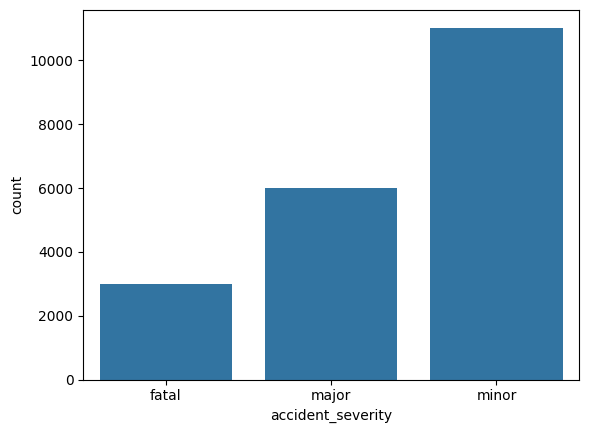

In [ ]:
sns.countplot(data=df,x='accident_severity')
plt.show()

## City wise Accidents

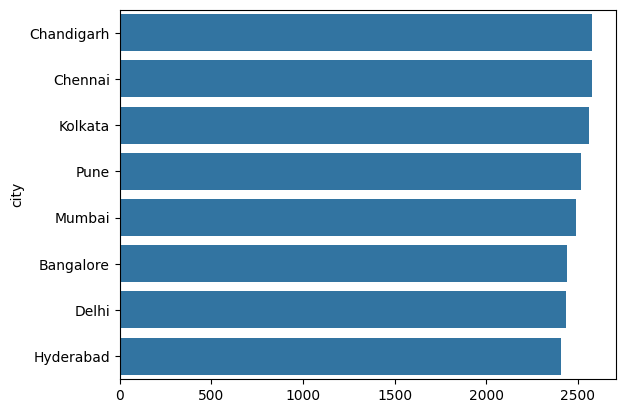

In [ ]:
top_cities = df['city'].value_counts().head(10)
sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)
plt.show()

## State wise Accidents

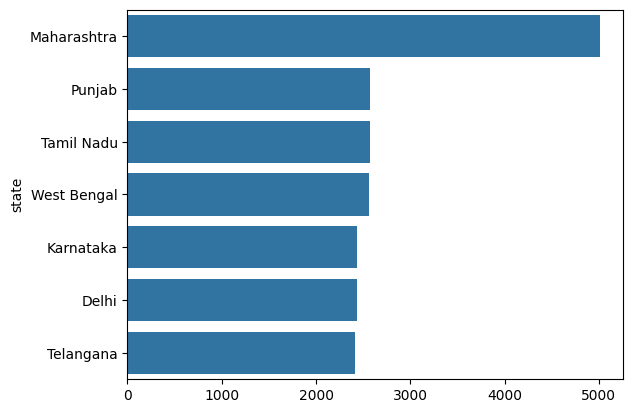

In [46]:
top_states = df['state'].value_counts().head(10)

sns.barplot(
    x=top_states.values,
    y=top_states.index
)
plt.show()

## Hours Analysis

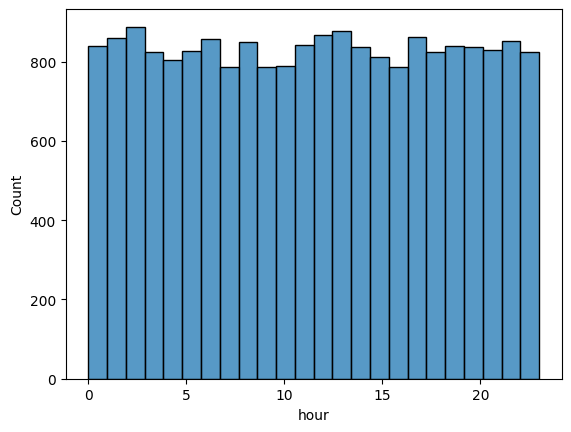

In [47]:
sns.histplot(df['hour'],bins=24)
plt.show()

## Day of Week Analysis

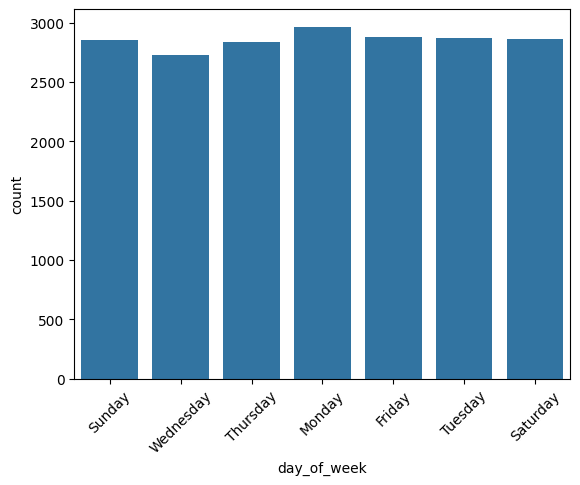

In [48]:
sns.countplot(
    data=df,
    x='day_of_week'
)
plt.xticks(rotation=45)
plt.show()

## Weather Impact

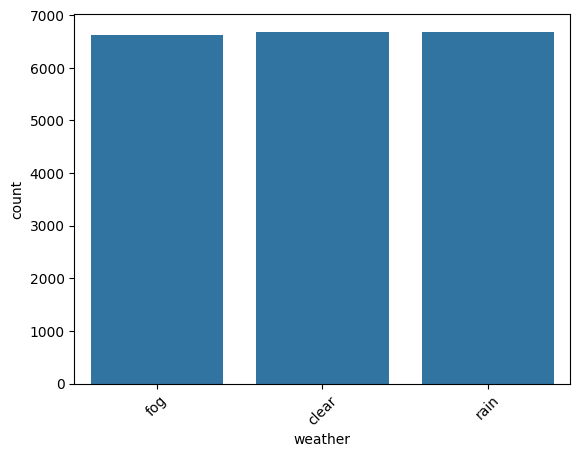

In [51]:
sns.countplot(
    data=df,
    x='weather'
)

plt.xticks(rotation=45)
plt.show()

In [52]:
pd.crosstab(
    df['weather'],
    df['accident_severity']
)

accident_severity,fatal,major,minor
weather,,,
clear,992,2017,3681
fog,995,1975,3663
rain,1000,1996,3681


## Road Type Analysis

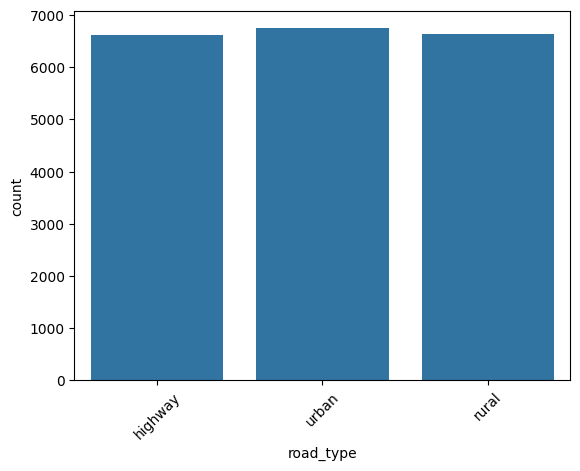

In [53]:
sns.countplot(
    data=df,
    x='road_type'
)
plt.xticks(rotation=45)
plt.show()

## Traffic Density

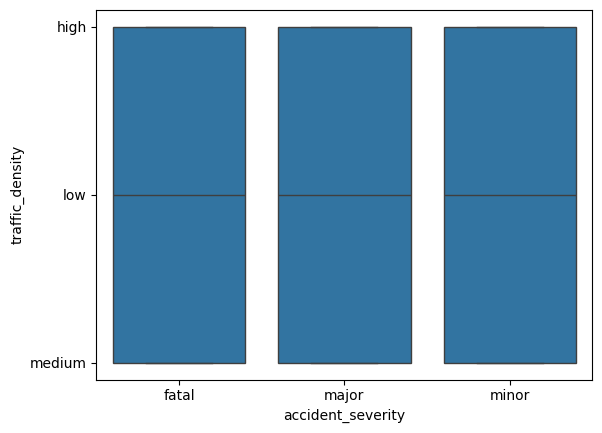

In [54]:
sns.boxplot(
    data=df,
    x='accident_severity',
    y='traffic_density'
)
plt.show()

## Visibility Analysis

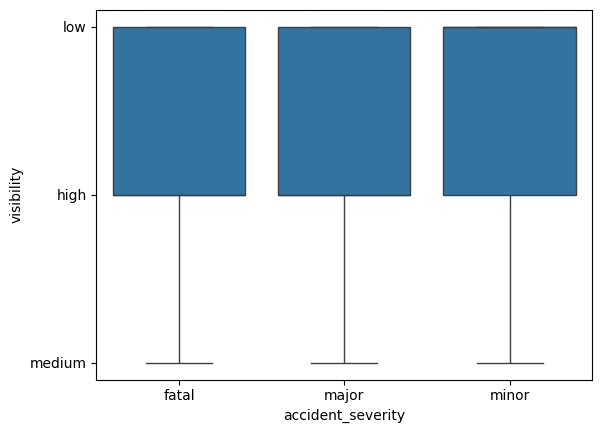

In [55]:
sns.boxplot(
    data=df,
    x='accident_severity',
    y='visibility'
)
plt.show()

## Temperature Analysis

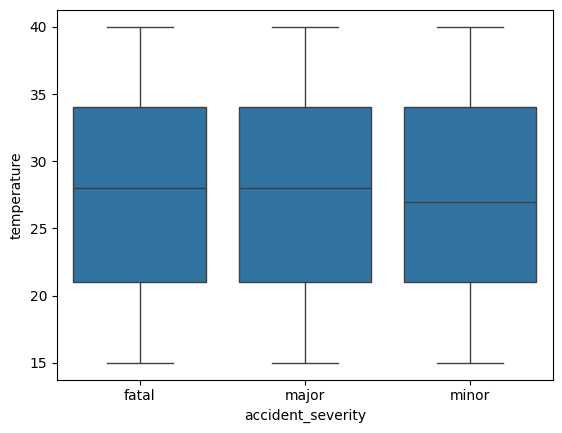

In [56]:
sns.boxplot(
    data=df,
    x='accident_severity',
    y='temperature'
)
plt.show()

## Correlation Matrix

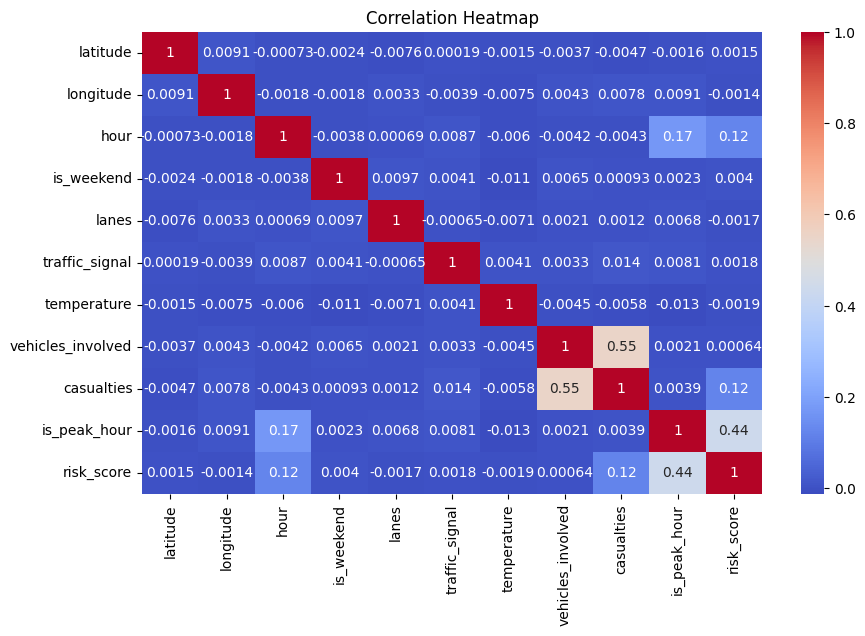

In [59]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr = numeric_df.corr()

# Plot
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Peak Hour Analysis

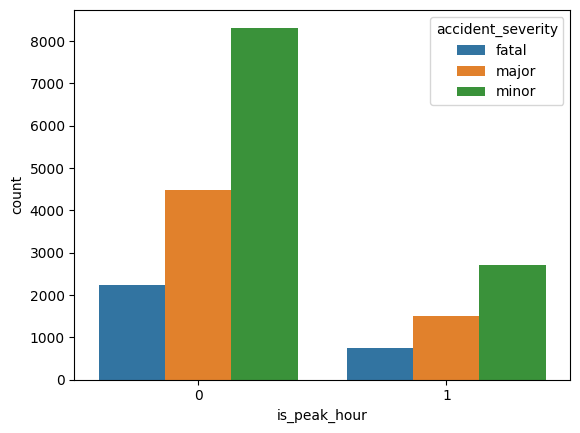

In [60]:
sns.countplot(
    data=df,
    x='is_peak_hour',
    hue='accident_severity'
)
plt.show()

## Hotspot Preview

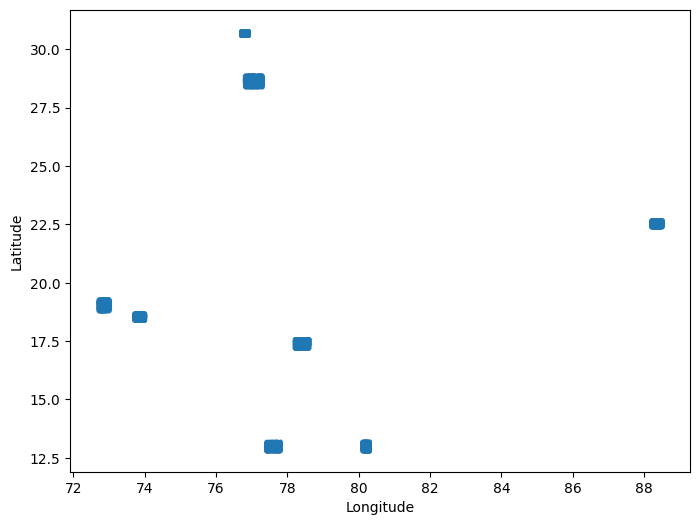

In [61]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['longitude'],
    df['latitude'],
    alpha=0.2,
    s=5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [62]:
df.to_csv('../data/cleaned_accidents.csv', index=False)